In [20]:
import subprocess
subprocess.run(["pip", "install", "scikit-learn", "matplotlib", "seaborn", "pymc", "arviz", "-q"], check=True)
print("All libraries ready")

All libraries ready


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.impute import SimpleImputer


In [22]:
print("\n>>> LOADING MERGED DATASETS")

merged_2011 = pd.read_csv("merged_2011.csv")
merged_2021 = pd.read_csv("merged_2021.csv")

# Build combined long-format for Bayesian analysis
merged_2011["year"] = 2011
merged_2021["year"] = 2021
combined = pd.concat([merged_2011, merged_2021], ignore_index=True)

print("2011 shape:", merged_2011.shape)
print("2011 columns:", list(merged_2011.columns))
print()
print("2021 shape:", merged_2021.shape)
print("2021 columns:", list(merged_2021.columns))



>>> LOADING MERGED DATASETS
2011 shape: (317, 27)
2011 columns: ['geo_code', 'area_name', 'pct_owned_total', 'pct_owned_outright', 'pct_owned_mortgage', 'pct_social_rented_total', 'pct_private_rented_total', 'pct_rent_free', 'pct_overcrowded_total', 'pct_occ_minus1', 'pct_occ_minus2_less', 'pct_occ_zero', 'pct_occ_plus1', 'pct_occ_plus2_more', 'pct_deprived_0', 'pct_deprived_1', 'pct_deprived_2', 'pct_deprived_3', 'pct_deprived_4', 'pct_multi_deprived', 'pct_any_deprived', 'pct_unemployed', 'pct_employed_total', 'pct_inactive_total', 'pct_inactive_sick', 'pct_self_employed', 'year']

2021 shape: (317, 15)
2021 columns: ['geo_code', 'area_name', 'pct_owned_total', 'pct_owned_outright', 'pct_social_rented_total', 'pct_private_rented_total', 'pct_rent_free', 'pct_deprived_0', 'pct_deprived_1', 'pct_deprived_2', 'pct_deprived_3', 'pct_deprived_4', 'pct_multi_deprived', 'pct_any_deprived', 'year']


In [23]:
# Detect available pct_ features in each dataset
feat_2011 = [c for c in merged_2011.columns if c.startswith("pct_")]
feat_2021 = [c for c in merged_2021.columns if c.startswith("pct_")]
feat_common = [c for c in feat_2021 if c in merged_2011.columns]

print(f"2011 pct_ features found : {len(feat_2011)} → {feat_2011}")
print(f"2021 pct_ features found : {len(feat_2021)} → {feat_2021}")
print(f"Common features (both)   : {len(feat_common)} → {feat_common}")

CAN_DO_2011_PCA = len(feat_2011) >= 2
CAN_DO_COMMON   = len(feat_common) >= 2

if not CAN_DO_2011_PCA:
    print("\nWARNING: merged_2011.csv has no pct_ feature columns."
          " PCA/t-SNE will run on 2021 only."
          " Re-run the preprocessing pipeline to regenerate merged_2011.csv with features.")

imputer = SimpleImputer(strategy="mean")
scaler  = StandardScaler()

# Always prepare 2021
X_2021        = imputer.fit_transform(merged_2021[feat_2021])
X_2021_scaled = scaler.fit_transform(X_2021)
print("\n2021 feature matrix:", X_2021_scaled.shape)

# Prepare 2011 only if it has features
if CAN_DO_2011_PCA:
    X_2011        = imputer.fit_transform(merged_2011[feat_2011])
    X_2011_scaled = scaler.fit_transform(X_2011)
    print("2011 feature matrix:", X_2011_scaled.shape)
else:
    X_2011_scaled = None

print("Scaling done.")


2011 pct_ features found : 24 → ['pct_owned_total', 'pct_owned_outright', 'pct_owned_mortgage', 'pct_social_rented_total', 'pct_private_rented_total', 'pct_rent_free', 'pct_overcrowded_total', 'pct_occ_minus1', 'pct_occ_minus2_less', 'pct_occ_zero', 'pct_occ_plus1', 'pct_occ_plus2_more', 'pct_deprived_0', 'pct_deprived_1', 'pct_deprived_2', 'pct_deprived_3', 'pct_deprived_4', 'pct_multi_deprived', 'pct_any_deprived', 'pct_unemployed', 'pct_employed_total', 'pct_inactive_total', 'pct_inactive_sick', 'pct_self_employed']
2021 pct_ features found : 12 → ['pct_owned_total', 'pct_owned_outright', 'pct_social_rented_total', 'pct_private_rented_total', 'pct_rent_free', 'pct_deprived_0', 'pct_deprived_1', 'pct_deprived_2', 'pct_deprived_3', 'pct_deprived_4', 'pct_multi_deprived', 'pct_any_deprived']
Common features (both)   : 12 → ['pct_owned_total', 'pct_owned_outright', 'pct_social_rented_total', 'pct_private_rented_total', 'pct_rent_free', 'pct_deprived_0', 'pct_deprived_1', 'pct_deprived_2

PCA on 2011 Data

In [24]:
if CAN_DO_2011_PCA:
    pca_2011 = PCA(n_components=2, random_state=42)
    pca_2011_coords = pca_2011.fit_transform(X_2011_scaled)

    print("PCA 2011 explained variance ratio:", pca_2011.explained_variance_ratio_)
    print(f"  PC1: {pca_2011.explained_variance_ratio_[0]*100:.1f}%")
    print(f"  PC2: {pca_2011.explained_variance_ratio_[1]*100:.1f}%")
    print(f"  Total: {sum(pca_2011.explained_variance_ratio_)*100:.1f}%")

    loadings_2011 = pd.DataFrame(
        pca_2011.components_.T,
        index=feat_2011, columns=["PC1", "PC2"]
    ).round(3)
    print("\nPCA 2011 Loadings:")
    print(loadings_2011)
else:
    pca_2011 = None
    pca_2011_coords = None
    print("Skipped: merged_2011.csv has no feature columns.")


PCA 2011 explained variance ratio: [0.51068982 0.23067873]
  PC1: 51.1%
  PC2: 23.1%
  Total: 74.1%

PCA 2011 Loadings:
                            PC1    PC2
pct_owned_total          -0.239  0.180
pct_owned_outright       -0.213  0.169
pct_owned_mortgage       -0.173  0.119
pct_social_rented_total   0.226 -0.054
pct_private_rented_total  0.179 -0.238
pct_rent_free            -0.002 -0.096
pct_overcrowded_total     0.222 -0.220
pct_occ_minus1            0.225 -0.222
pct_occ_minus2_less       0.203 -0.203
pct_occ_zero              0.220 -0.222
pct_occ_plus1            -0.069  0.354
pct_occ_plus2_more       -0.248  0.128
pct_deprived_0           -0.244 -0.175
pct_deprived_1            0.129 -0.106
pct_deprived_2            0.206  0.272
pct_deprived_3            0.258  0.155
pct_deprived_4            0.261 -0.058
pct_multi_deprived        0.235  0.229
pct_any_deprived          0.244  0.175
pct_unemployed            0.245  0.118
pct_employed_total       -0.193 -0.234
pct_inactive_total    

PCA on 2021 Data

In [25]:
pca_2021 = PCA(n_components=2, random_state=42)
pca_2021_coords = pca_2021.fit_transform(X_2021_scaled)

print("PCA 2021 explained variance ratio:", pca_2021.explained_variance_ratio_)
print(f"  PC1: {pca_2021.explained_variance_ratio_[0]*100:.1f}%")
print(f"  PC2: {pca_2021.explained_variance_ratio_[1]*100:.1f}%")
print(f"  Total: {sum(pca_2021.explained_variance_ratio_)*100:.1f}%")

loadings_2021 = pd.DataFrame(
    pca_2021.components_.T,
    index=feat_2021, columns=["PC1", "PC2"]
).round(3)
print("\nPCA 2021 Loadings:")
print(loadings_2021)


PCA 2021 explained variance ratio: [0.59891426 0.23537568]
  PC1: 59.9%
  PC2: 23.5%
  Total: 83.4%

PCA 2021 Loadings:
                            PC1    PC2
pct_owned_total          -0.273  0.382
pct_owned_outright       -0.233  0.423
pct_social_rented_total   0.273 -0.264
pct_private_rented_total  0.204 -0.361
pct_rent_free             0.255 -0.132
pct_deprived_0           -0.329 -0.280
pct_deprived_1            0.179  0.411
pct_deprived_2            0.333  0.250
pct_deprived_3            0.351  0.074
pct_deprived_4            0.296 -0.168
pct_multi_deprived        0.347  0.188
pct_any_deprived          0.329  0.280


In [26]:
# Build result DataFrames
pca_2021_df = pd.DataFrame(pca_2021_coords, columns=["PC1", "PC2"])
pca_2021_df["geo_code"]  = merged_2021["geo_code"].values
pca_2021_df["area_name"] = merged_2021["area_name"].values
pca_2021_df["year"]      = 2021

if CAN_DO_2011_PCA:
    pca_2011_df = pd.DataFrame(pca_2011_coords, columns=["PC1", "PC2"])
    pca_2011_df["geo_code"]  = merged_2011["geo_code"].values
    pca_2011_df["area_name"] = merged_2011["area_name"].values
    pca_2011_df["year"]      = 2011
    pca_combined = pd.concat([pca_2011_df, pca_2021_df], ignore_index=True)
else:
    pca_combined = pca_2021_df.copy()

pca_combined.to_csv("pca_results.csv", index=False)
print("Saved pca_results.csv")
print(pca_combined.head())


Saved pca_results.csv
        PC1       PC2   geo_code             area_name  year
0  3.577291  3.982882  E06000001            Hartlepool  2011
1  4.862771  3.365844  E06000002         Middlesbrough  2011
2  1.965576  3.716452  E06000003  Redcar and Cleveland  2011
3  0.103224  1.991945  E06000004      Stockton-on-Tees  2011
4  0.335368  1.311419  E06000005            Darlington  2011


t-SNE on 2011 Data

In [27]:
if CAN_DO_2011_PCA:
    tsne_2011 = TSNE(n_components=2, perplexity=30, random_state=42,
                     n_iter=1000, learning_rate="auto", init="pca")
    tsne_2011_coords = tsne_2011.fit_transform(X_2011_scaled)
    print("t-SNE 2011 done. Shape:", tsne_2011_coords.shape)
else:
    tsne_2011_coords = None
    print("Skipped: merged_2011.csv has no feature columns.")


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE 2011 done. Shape: (317, 2)


t-SNE on 2021 Data

In [28]:
tsne_2021 = TSNE(n_components=2, perplexity=30, random_state=42,
                 n_iter=1000, learning_rate="auto", init="pca")
tsne_2021_coords = tsne_2021.fit_transform(X_2021_scaled)
print("t-SNE 2021 done. Shape:", tsne_2021_coords.shape)

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE 2021 done. Shape: (317, 2)


In [29]:
tsne_2021_df = pd.DataFrame(tsne_2021_coords, columns=["TSNE1", "TSNE2"])
tsne_2021_df["geo_code"]  = merged_2021["geo_code"].values
tsne_2021_df["area_name"] = merged_2021["area_name"].values
tsne_2021_df["year"]      = 2021

if CAN_DO_2011_PCA and tsne_2011_coords is not None:
    tsne_2011_df = pd.DataFrame(tsne_2011_coords, columns=["TSNE1", "TSNE2"])
    tsne_2011_df["geo_code"]  = merged_2011["geo_code"].values
    tsne_2011_df["area_name"] = merged_2011["area_name"].values
    tsne_2011_df["year"]      = 2011
    tsne_combined = pd.concat([tsne_2011_df, tsne_2021_df], ignore_index=True)
else:
    tsne_combined = tsne_2021_df.copy()

tsne_combined.to_csv("tsne_results.csv", index=False)
print("Saved tsne_results.csv")
print(tsne_combined.head())


Saved tsne_results.csv
       TSNE1     TSNE2   geo_code             area_name  year
0  15.780694 -4.844238  E06000001            Hartlepool  2011
1  16.329386 -3.676052  E06000002         Middlesbrough  2011
2  10.298315 -4.156582  E06000003  Redcar and Cleveland  2011
3   4.485948 -1.762800  E06000004      Stockton-on-Tees  2011
4   3.405049 -0.887581  E06000005            Darlington  2011


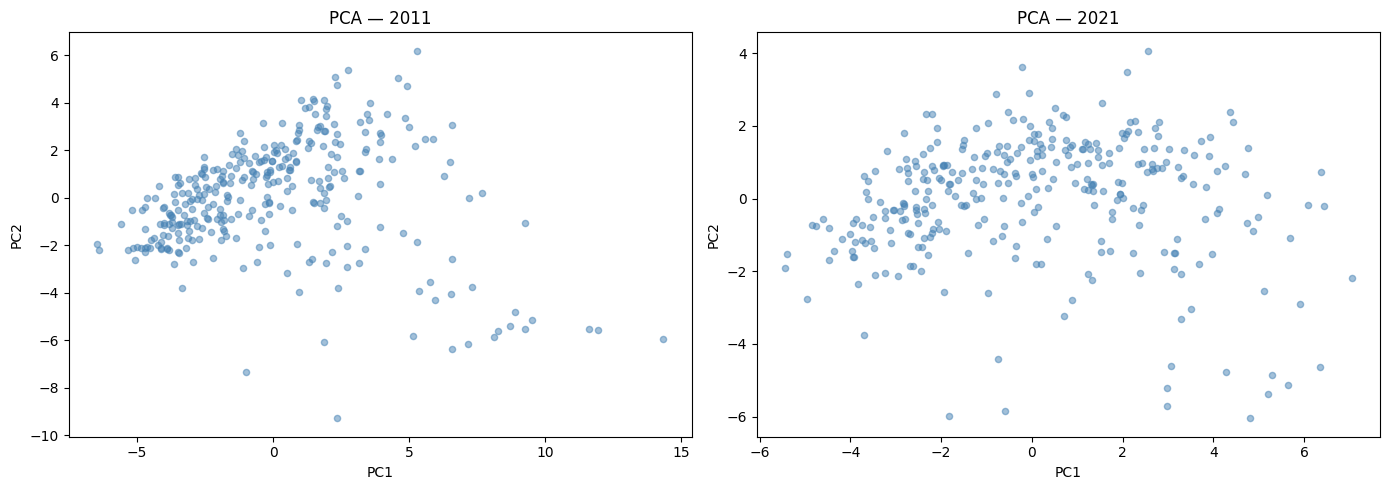

In [30]:
if CAN_DO_2011_PCA and pca_2011_coords is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    plot_pairs = [(axes[0], pca_2011_coords, "2011"),
                  (axes[1], pca_2021_coords, "2021")]
else:
    fig, axes = plt.subplots(1, 1, figsize=(7, 5))
    plot_pairs = [(axes, pca_2021_coords, "2021")]

for ax, coords, year in plot_pairs:
    ax.scatter(coords[:, 0], coords[:, 1], alpha=0.5, s=20, color="steelblue")
    ax.set_title(f"PCA — {year}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

plt.tight_layout()
plt.show()


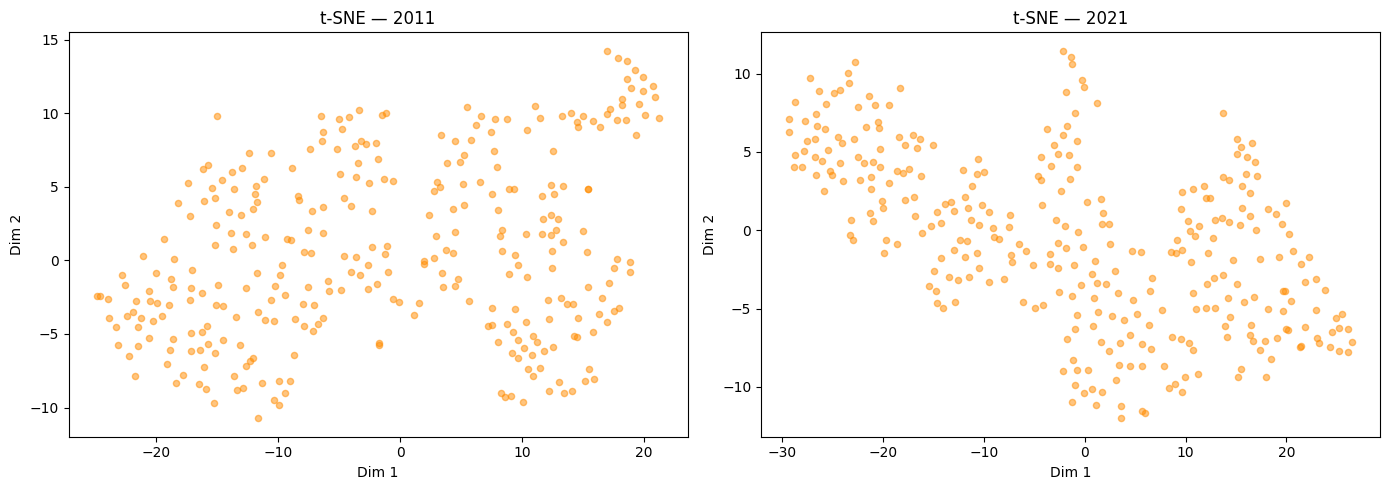

In [31]:
if CAN_DO_2011_PCA and tsne_2011_coords is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    plot_pairs = [(axes[0], tsne_2011_coords, "2011"),
                  (axes[1], tsne_2021_coords, "2021")]
else:
    fig, axes = plt.subplots(1, 1, figsize=(7, 5))
    plot_pairs = [(axes, tsne_2021_coords, "2021")]

for ax, coords, year in plot_pairs:
    ax.scatter(coords[:, 0], coords[:, 1], alpha=0.5, s=20, color="darkorange")
    ax.set_title(f"t-SNE — {year}")
    ax.set_xlabel("Dim 1")
    ax.set_ylabel("Dim 2")

plt.tight_layout()
plt.show()


Bayesian Regression: Private Renting Trend (2011 → 2021 → 2030)

In [32]:
import pymc as pm
import arviz as az

# Use % private rented per LAD across 2011 and 2021 as two observations
# Stack into long format: one row per LAD per year
bayes_df = combined[["geo_code", "area_name", "year", "pct_private_rented_total"]].dropna()

# Encode year as 0=2011, 1=2021 for modelling
bayes_df = bayes_df.copy()
bayes_df["year_idx"] = (bayes_df["year"] - 2011) / 10  # scaled: 0 and 1

y = bayes_df["pct_private_rented_total"].values
x = bayes_df["year_idx"].values

print(f"Bayesian model input: {len(y)} observations")
print(f"y mean: {y.mean():.2f}, y std: {y.std():.2f}")

Bayesian model input: 634 observations
y mean: 17.63, y std: 6.11


In [33]:
with pm.Model() as tenure_model:
    # Priors — weakly informative based on known housing data range
    alpha = pm.Normal("alpha", mu=y.mean(), sigma=10)   # intercept
    beta  = pm.Normal("beta",  mu=0,        sigma=5)    # trend per decade
    sigma = pm.HalfNormal("sigma", sigma=5)             # noise

    mu = alpha + beta * x

    # Likelihood
    likelihood = pm.Normal("y", mu=mu, sigma=sigma, observed=y)

    # Sample posterior
    trace = pm.sample(2000, tune=1000, return_inferencedata=True,
                      progressbar=True, random_seed=42)

az.summary(trace, var_names=["alpha", "beta", "sigma"])

Output()

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,15.894,0.327,15.323,16.545,0.007,0.005,2221.0,2858.0,1.0
beta,3.454,0.456,2.594,4.286,0.009,0.006,2461.0,2542.0,1.0
sigma,5.880,0.169,5.544,6.178,0.003,0.003,2628.0,2494.0,1.0


In [34]:
# year_idx for 2030 = (2030-2011)/10 = 1.9
x_pred = np.array([0, 1, 1.9])  # 2011, 2021, 2030
years_pred = [2011, 2021, 2030]

alpha_samples = trace.posterior["alpha"].values.flatten()
beta_samples  = trace.posterior["beta"].values.flatten()

preds = np.outer(beta_samples, x_pred) + alpha_samples[:, None]

pred_mean = preds.mean(axis=0)
pred_lower = np.percentile(preds, 2.5,  axis=0)
pred_upper = np.percentile(preds, 97.5, axis=0)

pred_df = pd.DataFrame({
    "year":       years_pred,
    "mean_pct_private_rented":  pred_mean.round(2),
    "lower_95ci": pred_lower.round(2),
    "upper_95ci": pred_upper.round(2),
})

pred_df.to_csv("bayesian_forecast.csv", index=False)
print("Saved bayesian_forecast.csv")

Saved bayesian_forecast.csv


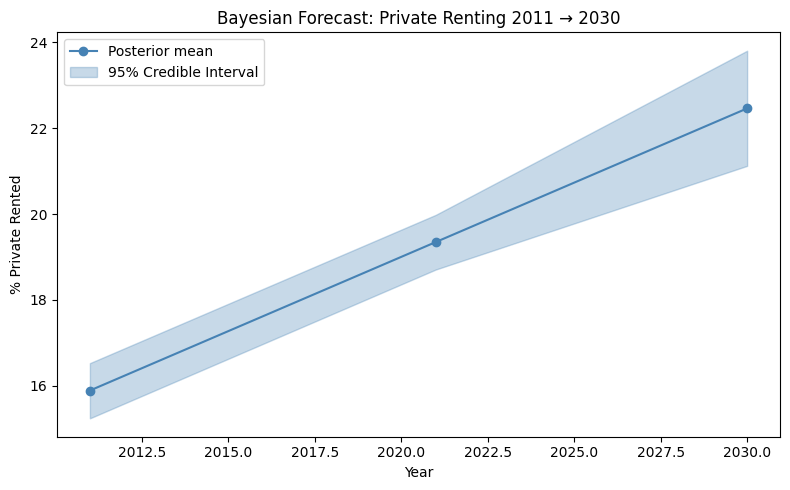

In [35]:
plt.figure(figsize=(8, 5))
plt.plot(years_pred, pred_mean, "o-", color="steelblue", label="Posterior mean")
plt.fill_between(years_pred, pred_lower, pred_upper, alpha=0.3,
                 color="steelblue", label="95% Credible Interval")
plt.xlabel("Year")
plt.ylabel("% Private Rented")
plt.title("Bayesian Forecast: Private Renting 2011 → 2030")
plt.legend()
plt.tight_layout()
plt.show()
